In [1]:
import os, sys

import IPython.display as ipd

path= '/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation'
sys.path.append(path)

import pandas as pd
import gemmi
import matplotlib.pyplot as plt
import meteor
import reciprocalspaceship as rs
from occupancy import *
from plotting3d import *
%load_ext autoreload 
%autoreload 2

from generate_objects import run_scaleit

In [2]:
folderloc =  '../photolyase_share_reviewers/'
dataloc_dark  = folderloc + '1_superdark/superdark_deposit.mtz'
pdbloc_dark  = folderloc + '1_superdark/superdark_deposit.pdb'
dataloc_light = folderloc + "7_30ns/30ns_deposit.mtz"
ds_light = rs.read_mtz(dataloc_light)
ds_dark = rs.read_mtz(dataloc_dark)




# Best Way to access row in rs?

In [132]:

ds_dark.loc[pd.IndexSlice[0,0,6]]

I-obs                 284157.84375
SIGI-obs              28358.560547
R-free-flags                     6
F-obs-filtered         3381.124023
SIGF-obs-filtered       186.983047
F-model                3328.107178
PHIF-model                     0.0
2FOFCWT                3773.437256
PH2FOFCWT                      0.0
2FOFCWT_no_fill        3773.437256
PH2FOFCWT_no_fill              0.0
FOFCWT                   79.419266
PHFOFCWT                       0.0
sf                   (3381.124+0j)
Name: (0, 0, 6), dtype: object

In [167]:
ds_dark

I-obs      SIGI-obs  R-free-flags  F-obs-filtered  \
H  K  L                                                              
0  0  6   284157.84375  28358.560547             6     3381.124023   
      8     114.540741     38.163765            17       67.087746   
      10   4017.811523    139.221115             8      421.545776   
      12  46658.433594   1461.593262            11     1435.483765   
      14   1479.636963     58.852287             0      255.786545   
...                ...           ...           ...             ...   
57 14 5            NaN           NaN             1             NaN   
      6            NaN           NaN             6             NaN   
0  0  2            NaN           NaN           NaN             NaN   
   1  1            NaN           NaN           NaN             NaN   
      2            NaN           NaN           NaN             NaN   

          SIGF-obs-filtered      F-model  PHIF-model      2FOFCWT  PH2FOFCWT  \
H  K  L                                                                        
0  0  6          186.983047  3328.107178         0.0  3773.437256        0.0   
      8           14.345318     8.001706         0.0     0.535461        0.0   
      10           7.316233   441.704254         0.0   471.327728        0.0   
      12          22.552881  1184.225586       180.0  1559.282227      180.0   
      14           5.098086   183.673569       180.0     154.3396      180.0   
...                     ...          ...         ...          ...        ...   
57 14 5                 NaN          NaN         NaN          NaN        NaN   
      6                 NaN          NaN         NaN          NaN        NaN   
0  0  2                 NaN          NaN         NaN  6173.225586        0.0   
   1  1                 NaN          NaN         NaN  3479.721191       90.0   
      2                 NaN          NaN         NaN  1941.794922      -90.0   

          2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  \
H  K  L                                                              
0  0  6       3773.437256                0.0   79.419266       0.0   
      8          0.535461                0.0    8.313123     180.0   
      10       471.327728                0.0   26.647619     180.0   
      12      1559.282227              180.0  279.940491     180.0   
      14         154.3396              180.0   43.214062       0.0   
...                   ...                ...         ...       ...   
57 14 5               NaN                NaN         NaN       NaN   
      6               NaN                NaN         NaN       NaN   
0  0  2               NaN                NaN         NaN       NaN   
   1  1               NaN                NaN         NaN       NaN   
      2               NaN                NaN         NaN       NaN   

                                sf  
H  K  L                             
0  0  6   3381.124023+   0.000000j  
      8     67.087746+   0.000000j  
      10   421.545776+   0.000000j  
      12 -1435.483765-   0.000125j  
      14  -255.786545-   0.000022j  
...                            ...  
57 14 5           NaN+        NaNj  
      6           NaN+        NaNj  
0  0  2           NaN+        NaNj  
   1  1           NaN+        NaNj  
      2           NaN+        NaNj  

[418451 rows x 14 columns]

In [168]:

ds_light 

IMEAN       SIGIMEAN           F       SIGF       KFEXTR  \
H  K L                                                                   
0  0 2          NaN            NaN         NaN        NaN          NaN   
     4          NaN            NaN         NaN        NaN          NaN   
     6   563041.625  124030.234375  733.373047  87.899185  3107.084473   
     7 -1661.612183    1027.905151    12.38824   8.876429          NaN   
     8  -470.827209     346.035034    7.571723   5.376757    58.114021   
...             ...            ...         ...        ...          ...   
35 3 3          NaN            NaN         NaN        NaN          NaN   
     4          NaN            NaN         NaN        NaN          NaN   
   4 0          NaN            NaN         NaN        NaN          NaN   
     1          NaN            NaN         NaN        NaN          NaN   
     2          NaN            NaN         NaN        NaN          NaN   

        SIGKFEXTR  R-free-flags      F-model  PHIF-model      2FOFCWT  \
H  K L                                                                  
0  0 2        NaN           NaN          NaN         NaN  6650.478516   
     4        NaN            14          NaN         NaN  1927.483765   
     6  16.496628             6  3358.235596         0.0  3301.962158   
     7        NaN           NaN          NaN         NaN          NaN   
     8  40.554333            17   168.217529         0.0     2.425961   
...           ...           ...          ...         ...          ...   
35 3 3        NaN             6          NaN         NaN          NaN   
     4        NaN            19          NaN         NaN          NaN   
   4 0        NaN            12          NaN         NaN          NaN   
     1        NaN            10          NaN         NaN          NaN   
     2        NaN             0          NaN         NaN          NaN   

        PH2FOFCWT  2FOFCWT_no_fill  PH2FOFCWT_no_fill      FOFCWT  PHFOFCWT  
H  K L                                                                       
0  0 2        0.0              NaN                NaN         NaN       NaN  
     4        0.0              NaN                NaN         NaN       NaN  
     6        0.0      3301.962158                0.0  752.040527       0.0  
     7        NaN              NaN                NaN         NaN       NaN  
     8        0.0         2.425961                0.0  124.879761     180.0  
...           ...              ...                ...         ...       ...  
35 3 3        NaN              NaN                NaN         NaN       NaN  
     4        NaN              NaN                NaN         NaN       NaN  
   4 0        NaN              NaN                NaN         NaN       NaN  
     1        NaN              NaN                NaN         NaN       NaN  
     2        NaN              NaN                NaN         NaN       NaN  

[96220 rows x 15 columns]

In [5]:
dark_struc = gemmi.read_structure(pdbloc_dark)

dark_struc.cell

<gemmi.UnitCell(70.2, 117.76, 170.47, 90, 90, 90)>

In [6]:

ds_dark["sf"] = ds_dark.to_structurefactor("F-obs-filtered", "PHIF-model")
f_dark = ds_dark.to_reciprocal_grid("sf")
f_light = (ds_light.to_reciprocal_grid("IMEAN"))


In [8]:
def get_fxtr(ds_comb, dark_f, light_f, dark_phi,alphas):
    ds_comb["sf_dark"] = ds_comb.to_structurefactor(dark_f, dark_phi)
    diff = ds_comb[light_f] - ds_comb[dark_f]
    ds_comb["F_delta"] = np.abs(diff)
    ds_comb["delta_phi"] = ds_comb[dark_phi]+(np.sign(diff)<0)*180
    ds_comb["sf_delta"] = ds_comb.to_structurefactor("F_delta", "delta_phi")
    f_dark = ds_comb.to_reciprocal_grid( "sf_dark")
    f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
    print(f_dark)
    f_xtrs = []
    for alpha in alphas:
        f_xtr = 2 / alpha * f_delta + f_dark
        f_xtrs.append(f_xtr)
    return np.array(f_xtrs), f_dark, f_delta


alphas = np.linspace(0.01, 0.99, 20)
alphas = np.linspace(0.05, 0.8, 7)
dark_f="F-obs-filtered"
dark_phi="PHIF-model"
light_f = "FMEAN"
phi_corr = "phi_corr"
light_sig = "SIG_light"
dark_sig = "SIGF-obs-filtered"

columns = {
        "light_f": light_f,
        "dark_f": dark_f,
        "light_sig": light_sig,
        "dark_sig": dark_sig,
}


ds_comb = ds_dark.copy()
ds_comb[light_f] = np.sqrt(np.abs(ds_light["IMEAN"]))
ds_comb[light_sig] = np.sqrt(np.abs(ds_light["SIGIMEAN"]))

ds_scaleit = rs.DataSet(cell=ds_comb.cell, spacegroup=ds_comb.spacegroup)
for column in columns.values():
    ds_scaleit[column] = ds_comb[column]

ds_scaleit = run_scaleit( ds_scaleit, None, False, columns=columns)

for column in columns.values():
    ds_comb[column] = ds_scaleit[column]

ds_comb[phi_corr] = (ds_light["IMEAN"]<0)*np.pi

Running scaleit, see launch_scaleit.sh


In [9]:
alphas = np.linspace(0.01, 0.99, 20)
dark_f="F-obs-filtered"
dark_phi="PHIF-model"
light_f = "FMEAN"
phi_corr = "phi_corr"
light_sig = "SIG_light"
dark_sig = "SIGF-obs-filtered" 
columns = {
        "light_f": light_f,
        "dark_f": dark_f,
        "light_sig": light_sig,
        "dark_sig": dark_sig,
}

# f_xtrs, f_dark, f_delta = get_fxtr(ds_comb, dark_f, light_f, dark_phi,alphas)


# ds_scaleit.reindexing_ops()

In [10]:
ds_comb

ds_scaleit

FMEAN  F-obs-filtered    SIG_light  SIGF-obs-filtered
H  K  L                                                              
0  0  6   3414.140625     3381.124023  1602.414673         186.983047
      8     98.728355       67.087746    84.639122          14.345318
      10   461.248169      421.545776   137.481445           7.316233
      12  1420.581177     1435.483765    363.78479          22.552881
      14   273.654114      255.786545    92.549942           5.098086
...               ...             ...          ...                ...
57 14 5           NaN             NaN          NaN                NaN
      6           NaN             NaN          NaN                NaN
0  0  2           NaN             NaN          NaN                NaN
   1  1           NaN             NaN          NaN                NaN
      2           NaN             NaN          NaN                NaN

[418451 rows x 4 columns]

In [133]:
ds_comb["sf_dark"] = ds_comb.to_structurefactor(dark_f, dark_phi)
ds_comb["F_delta"] = ds_comb[light_f] - ds_comb[dark_f]
ds_comb["sf_delta"] = ds_comb.to_structurefactor("F_delta", dark_phi)
ds_comb["sf_light"] = ds_comb.to_structurefactor(light_f, dark_phi)
f_dark = ds_comb.to_reciprocal_grid( "sf_dark")
f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
f_light = ds_comb.to_reciprocal_grid( "sf_light")
def struc2realio(f):
    f_prime = f.copy()
    f_prime[np.isnan(f)] = 0
    return np.real(np.fft.ifftn(f_prime))


In [143]:
f_dark[0,0,0]

0j

In [12]:
f_dark = ds_comb.to_reciprocal_grid( "sf_dark")
f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
f_light = ds_comb.to_reciprocal_grid( "sf_light")
f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0

from occupancy import make_f_xtr
f_angle = np.angle(f_dark)
f_xtrs =  make_f_xtr(alphas, f_dark, f_light, f_angle,version=1)

In [18]:
rho_dark = struc2realio(f_dark)
rho_light = struc2realio(f_light)
rho_delta_real = struc2realio(f_delta)

from scipy import ndimage
unit = np.array((
    dark_struc.cell.a,
    dark_struc.cell.b,
    dark_struc.cell.c
))
step_size = np.array(rho_delta.shape)/ unit
print(step_size)
sigma = np.mean(step_size) * 1.75
# rho_delta = density_lightT-density_darkT

dog_real_data = ndimage.gaussian_laplace(rho_delta_real, sigma=sigma)


[2.56410256 2.54755435 2.53417024]


0.0


interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

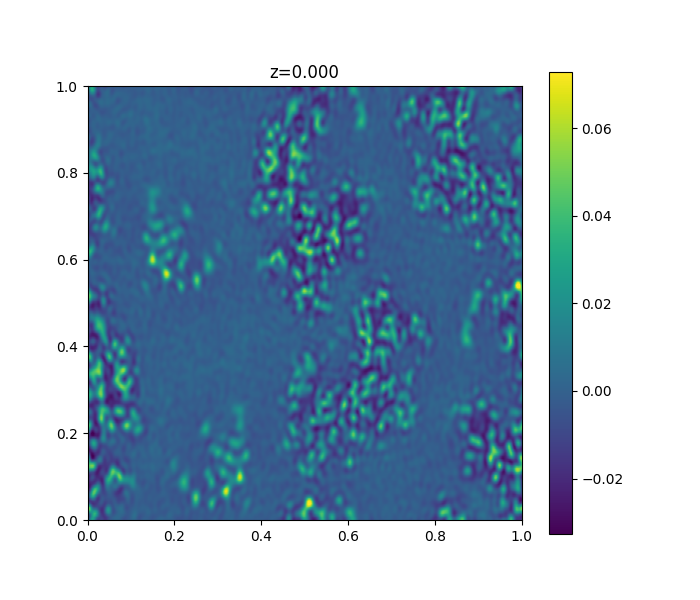

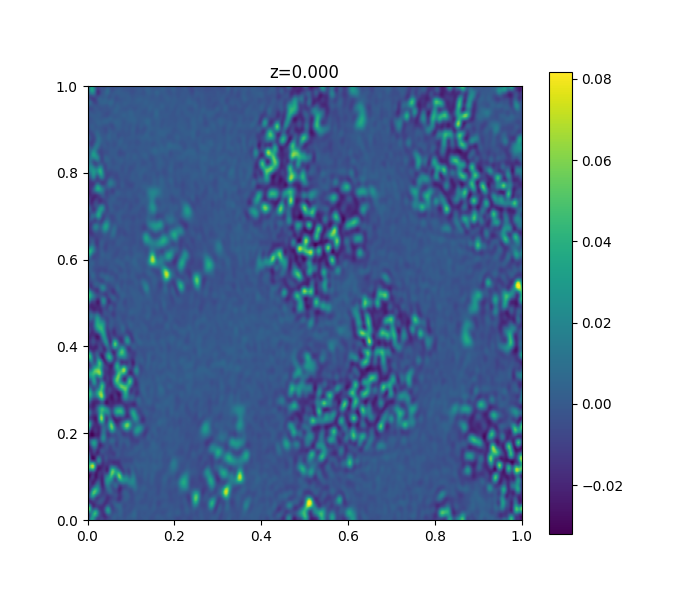

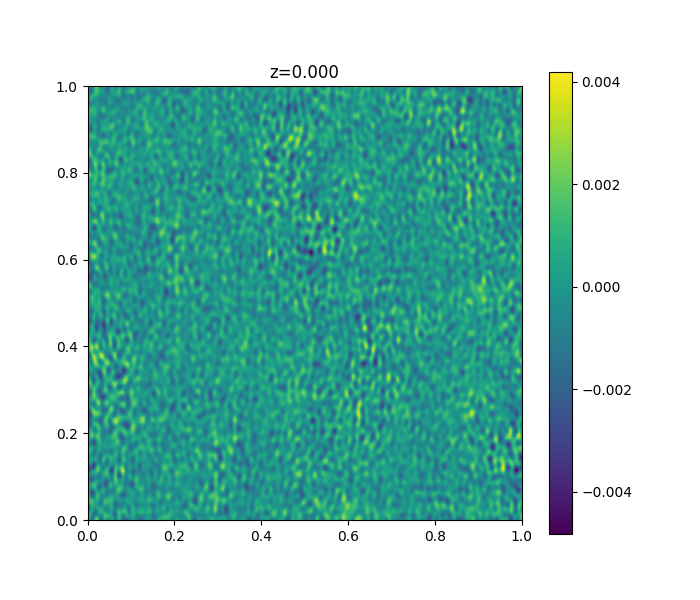

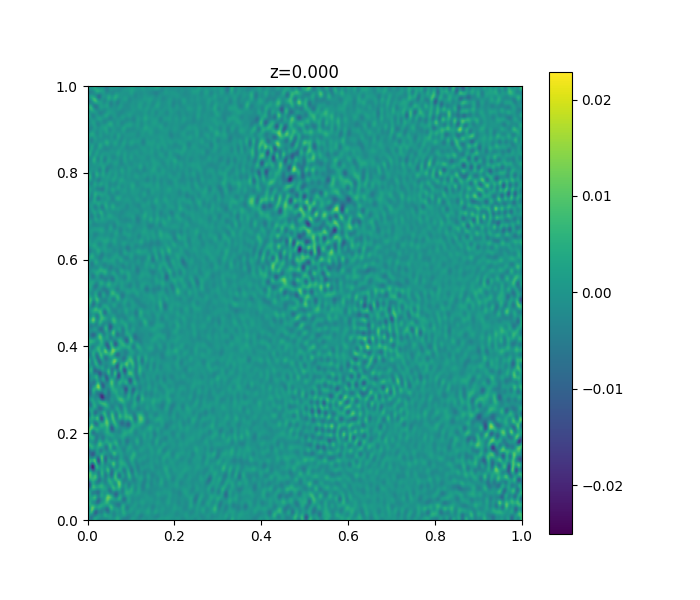

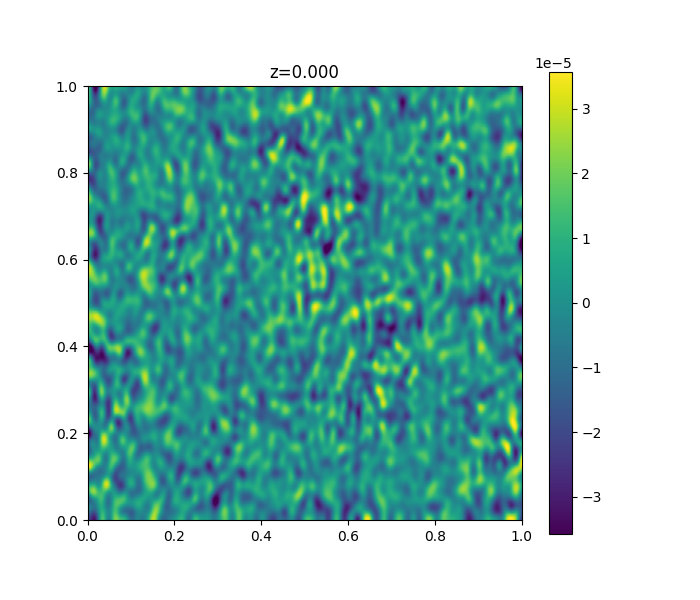

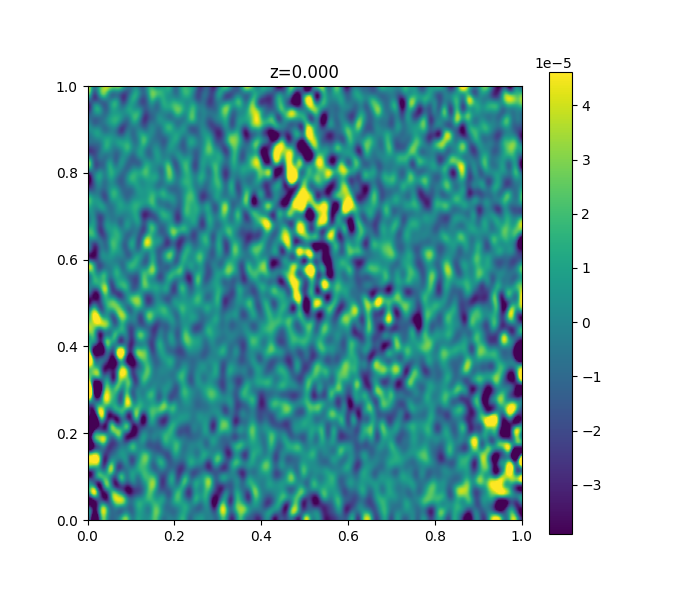

In [20]:
print(np.nanmax(np.real(np.imag(rho_dark))))
%matplotlib widget
_ = slice_3d(np.real(rho_light))
_ = slice_3d(np.real(rho_dark))
_ = slice_3d(np.real(rho_delta_real))
_ = slice_3d(np.real( rho_light - rho_dark) )
dog_real_data_v1 = ndimage.gaussian_laplace(rho_delta_real, sigma=sigma)
dog_real_data_v2 = ndimage.gaussian_laplace( rho_light- rho_dark, sigma=sigma)
_ = slice_3d(np.real(dog_real_data_v1) )
_ = slice_3d(np.real(dog_real_data_v2) )

# mask = 

In [15]:
from scipy.ndimage import gaussian_filter

sigma1 = 0.5
sigma2 = 2
blur1 = np.abs(gaussian_filter(rho_delta, sigma=sigma1))
blur2 = np.abs(gaussian_filter(rho_delta, sigma=sigma2))
dog = blur1-blur2


In [ ]:
_ = slice_3d(result)

In [24]:
from scipy import ndimage
def periodic_label_3d(label_image):
    for dim in range(label_image.ndim):
        for idx_1 in range(label_image.shape[dim]):
            for idx_2 in range(label_image.shape[(dim+1)%3]):
                first = tuple(np.roll((idx_1,idx_2,0),dim))
                last = tuple(np.roll((idx_1,idx_2,-1),dim))
                if label_image[first] > 0 and label_image[last] > 0:
                    label_image[label_image == label_image[last]] = label_image[first]
    return label_image

def periodic_label_3d(label_image):
    from collections import defaultdict

    class UnionFind:
        def __init__(self):
            self.parent = {}

        def find(self, x):
            root = x
            while self.parent.get(root, root) != root:
                root = self.parent[root]
            while x != root:
                self.parent[x], x = root, self.parent[x]
            return root

        def union(self, x, y):
            self.parent[self.find(x)] = self.find(y)

        def relabel(self, array):
            mapping = {label: self.find(label) for label in np.unique(array) if label > 0}
            out = array.copy()
            for old, new in mapping.items():
                if old != new:
                    out[array == old] = new
            return out

    uf = UnionFind()
    shape = label_image.shape

    for dim in range(3):
        axis1 = (dim + 1) % 3
        axis2 = (dim + 2) % 3

        for i in range(shape[axis1]):
            for j in range(shape[axis2]):
                idx_first = [0, 0, 0]
                idx_last  = [0, 0, 0]

                idx_first[dim] = 0
                idx_last[dim] = shape[dim] - 1

                idx_first[axis1] = i
                idx_last[axis1] = i

                idx_first[axis2] = j
                idx_last[axis2] = j

                a = label_image[tuple(idx_first)]
                b = label_image[tuple(idx_last)]

                if a > 0 and b > 0 and a != b:
                    uf.union(a, b)

    return uf.relabel(label_image)

def pick_largest(
    result,
    thresh_fac,
    nth_val = 70,
):
    idcs_flat = np.argpartition(result.flatten(),-nth_val)[-nth_val:]
    idcs=np.unravel_index(idcs_flat,result.shape)
    thresh = np.min(result[idcs])*thresh_fac
    mask_dog = (result) > thresh
    labeled_dog, total_num = ndimage.label(mask_dog)
    labeled_dog = periodic_label_3d( labeled_dog )
    # labeled_dog =label_periodic_3d_consistent(result, structure)

    
    
        # np.unique(labeled_dog, return_counts=True)
    idcs_labels = {}
    for idx in np.array(idcs).T:
        label = labeled_dog[tuple(idx)]
        if label not in idcs_labels.keys():
            size = np.sum(labeled_dog == label)
            idcs_labels[label] = size
    print(thresh,        idcs_labels)
    new_mask = np.zeros_like(labeled_dog)
    for key in     idcs_labels.keys():
        new_mask += labeled_dog==key
    return new_mask
# mask_pos = pick_largest( np.fft.fftshift(result), thresh_fac=0.35 ) 
# mask_neg = pick_largest( -np.fft.fftshift(result), 0.5, 40 ) 

mask_pos = pick_largest( (result), thresh_fac=0.35 ) 
mask_neg = pick_largest( -(result), 0.5, 40 ) 

2.237402132893913e-05 {582: 796, 659: 803, 283: 803, 206: 833, 737: 352}
2.82763312434033e-05 {132: 380, 67: 421, 246: 249}


In [27]:

# plt.figure()

# # labeled_dog[-1][labeled_dog[-1]==0]+600
# over = -np.array(labeled_dog[0]>0,int)+np.array(labeled_dog[-1]>0,int)
# plt.imshow(over)
# np.unique(labeled_dog[0])[1:]

In [28]:
# plt.imshow(over)


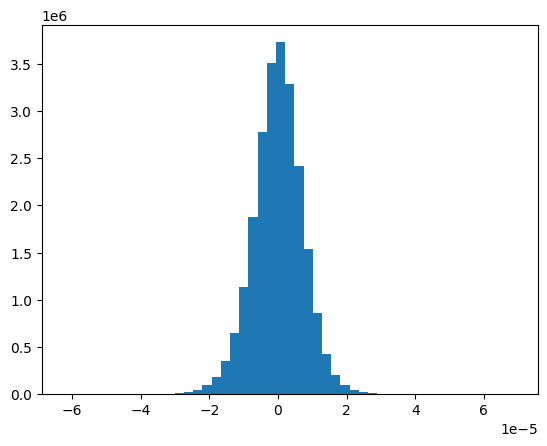

In [29]:
bins= np.linspace(np.min(result),np.max(result),50)
plt.figure()
_ = plt.hist(result.flatten(),bins=bins)


2.237402132893913e-05 {582: 796, 659: 803, 283: 803, 206: 833, 737: 352}
2.82763312434033e-05 {132: 380, 67: 421, 246: 249}


interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

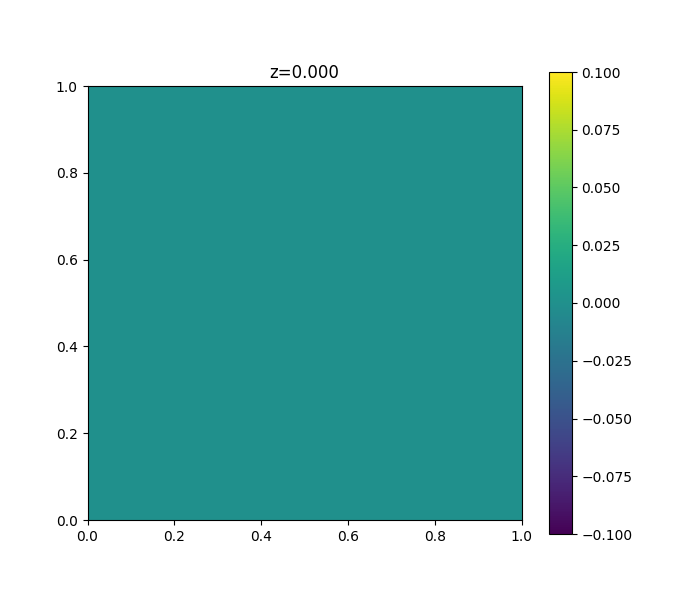

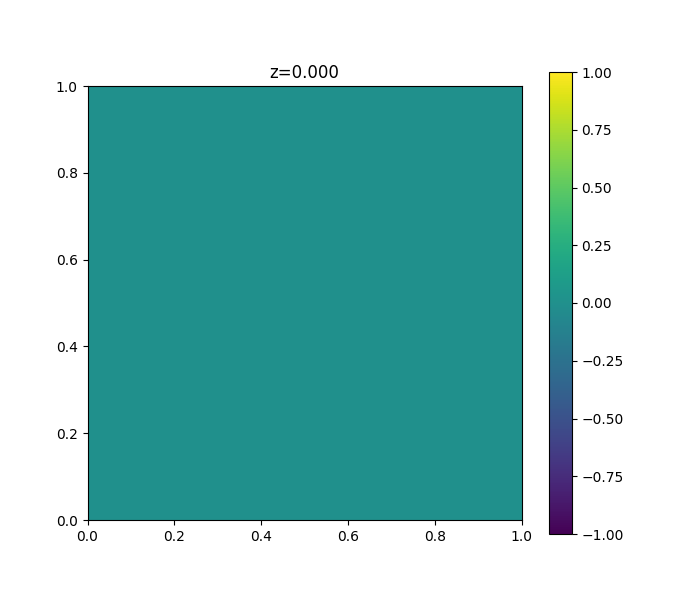

In [41]:
thresh_pos = 0.35
thresh_neg = 0.5
# thresh_pos = 2e-1
# thresh_neg = 2e-1

mask_pos = pick_largest( (result), thresh_fac=thresh_pos ) 
mask_neg = pick_largest( -(result), thresh_neg, 40 ) 
mask_comb = (mask_pos+mask_neg)>0
%matplotlib widget
_ = slice_3d(mask_comb)

_=slice_3d(mask_pos-mask_neg ,imkwargs={"vmax":1, "vmin": -1})


interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

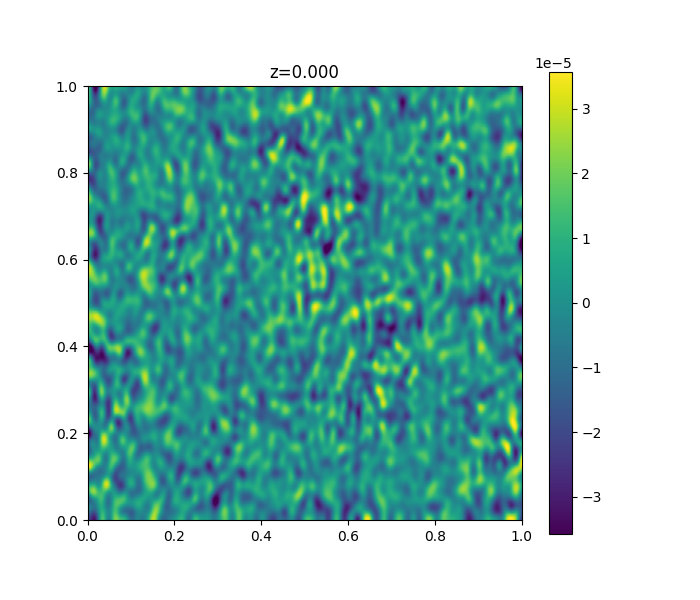

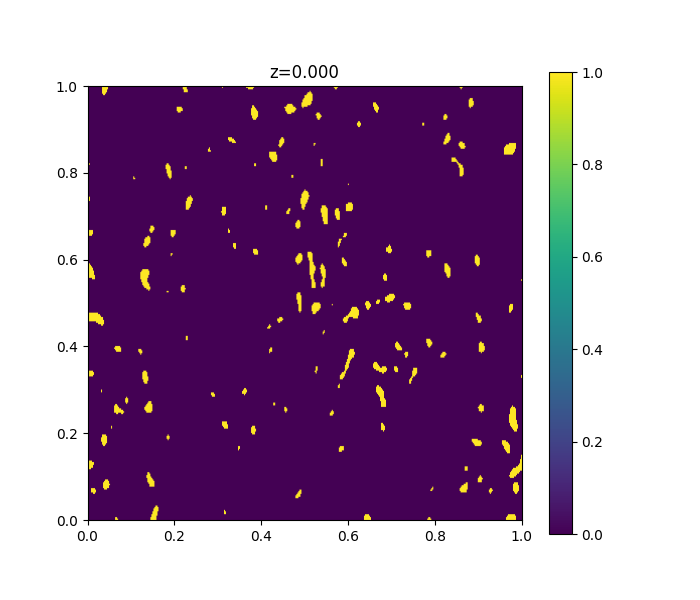

In [42]:
dog_mask = result>2e-5

_ = slice_3d(np.real(result))
_ = slice_3d(np.real(dog_mask))
# _ = slice_3d(np.real(blur1))
# _ = slice_3d(np.real(blur2))


In [43]:
from occupancy import *
from plotting3d import *
densities, neg_sum = marius(f_xtrs, mask_comb)



# Loading already phased result

In [46]:
names_dict = {
    # "photolyase10": "Photolyase 10 ns", 
    "photolyase30": "Photolyase 30 ns", 
    # "synthetic_cistrans": "rsEGFP2 (synth)",
    # "real_cistrans": "rsEGFP2 (meteor)",
    # "mpro": "MPRO (meteor)",
    # "doeke": "EFX protein (Doeke)",
}
import reciprocalspaceship as rs
def struc2realspace(struc, hs_limit, noise_level):
    map_vals = meteor.sfcalc.gemmi_structure_to_calculated_map(struc, high_resolution_limit=hs_limit)
    struc_vals=rs.DataSet(map_vals)
    noise = np.random.normal(loc=0.0, scale=noise_level * np.abs(struc_vals["F"]))
    struc_vals["F"] = struc_vals["F"] + noise
    struc_vals["sf"] = struc_vals.to_structurefactor("F","PHI")
    struc_vals_grid = struc_vals.to_reciprocal_grid("sf")
    struc_vals_real = np.fft.ifftn(struc_vals_grid).real
    return struc_vals_real

from generate_objects import get_pdb_pairs
for name in names_dict.keys():    
    pdb_pair = get_pdb_pairs(name)
    parent = "/Users/sbielfel/Nextcloud2/time_resolved/occupancy-estimation/"
    fname_dark = f"{parent}synthetic_data/{pdb_pair[0]}.pdb"
    fname_mix = f"{parent}synthetic_data/{pdb_pair[1]}.pdb"
    struc_dark = gemmi.read_structure(fname_dark)
    struc_light = gemmi.read_structure(fname_mix)
    density_darkT = struc2realspace(struc_dark, 1.2, 0)
    density_lightT = struc2realspace(struc_light, 1.2, 0)
print(density_darkT.shape)
print(density_lightT.shape)
unit = np.array((
    struc_dark.cell.a,
    struc_dark.cell.b,
    struc_dark.cell.c
))

(180, 300, 432)
(180, 300, 432)


In [24]:
from scipy import ndimage
unit = np.array((
    dark_struc.cell.a,
    dark_struc.cell.b,
    dark_struc.cell.c
))
step_size = np.array(rho_delta.shape)/ unit
print(step_size)
sigma = np.mean(step_size) * 1.75
rho_delta = density_lightT-density_darkT

result = ndimage.gaussian_laplace(rho_delta, sigma=sigma)

[2.56410256 2.54755435 2.53417024]


[2.56410256 2.54755435 2.53417024]


interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

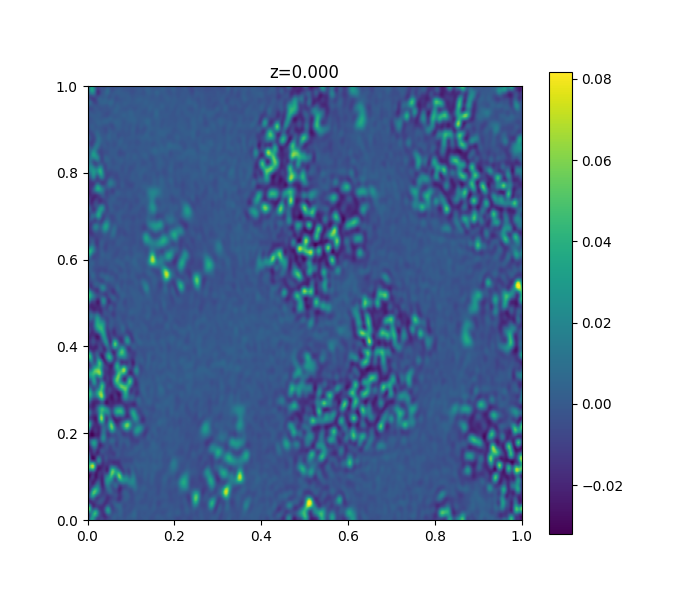

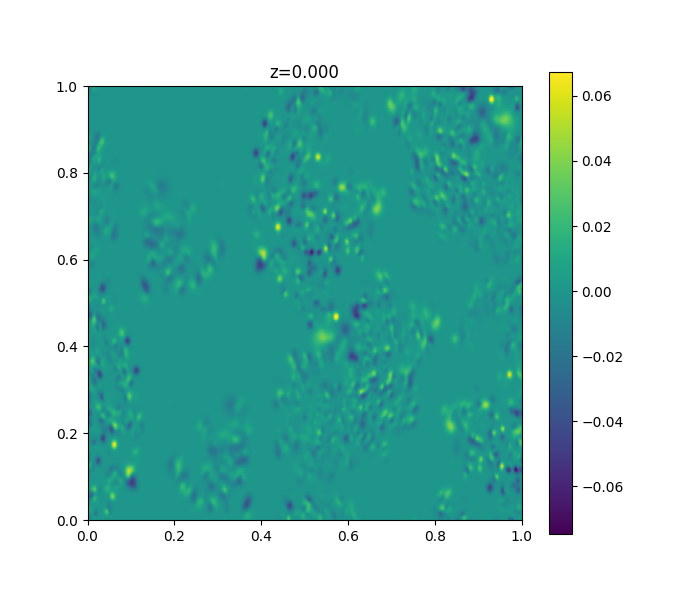

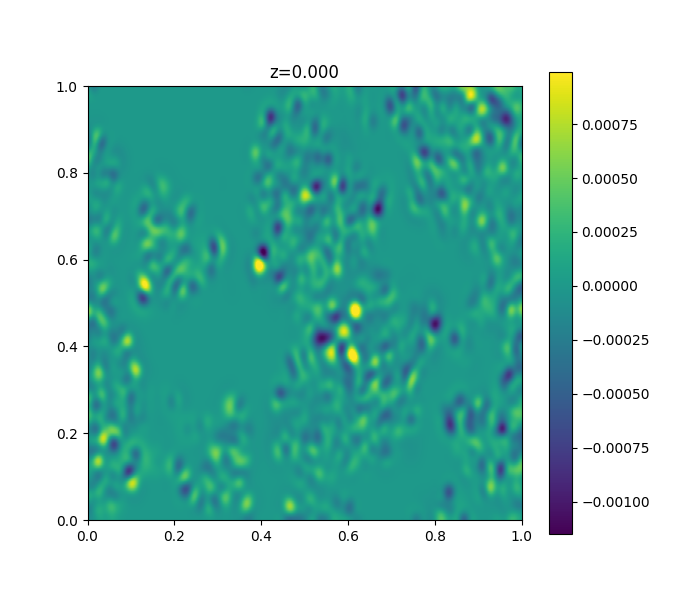

In [47]:
rho_delta = density_lightT-density_darkT
step_size = np.array(rho_delta.shape)/ unit
print(step_size)
sigma = np.mean(step_size) * 1.75
# slice_3d(density_dark)
# slice_3d(density_light)
result = ndimage.gaussian_laplace(rho_delta, sigma=sigma)
_ = slice_3d(rho_dark)
_ = slice_3d(rho_delta)
_ = slice_3d(result)
%matplotlib widget
# rho_delta[np.abs(rho_delta)<1e-5] = 0
# _ = slice_3d(rho_delta)

In [37]:
perc_size = 1e-4
perc_size = 4e-3
perc_high = np.percentile(rho_delta,100-perc_size)
perc_low = np.percentile(rho_delta,perc_size)
print(perc_low, perc_high)
mask_truth = np.logical_or(rho_delta>perc_high, rho_delta<perc_low)
mask_truth = np.logical_or(rho_delta>perc_high, rho_delta<perc_low)

-0.07670372393144184 0.08115989803322307


interactive(children=(IntSlider(value=0, description='f0', max=179), Output()), _dom_classes=('widget-interact…

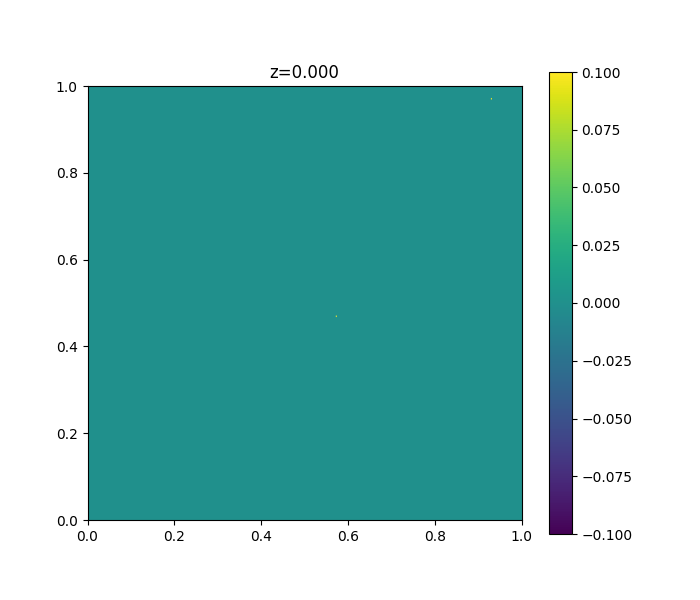

In [38]:
_ = slice_3d(mask_truth)

In [39]:
f_xtrs[0,0]

array([[0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       ...,
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, ..., 0.+0.j, 0.+0.j, 0.+0.j]])

In [21]:
densities, neg_sum = marius(f_xtrs, mask_comb )

n_largest = 3
alpha_invs = 2/alphas

NameError: name 'mask_comb' is not defined

(0.0, 300.0)

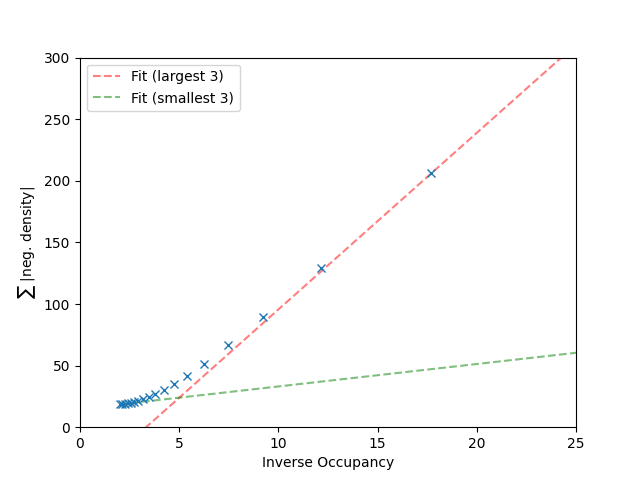

In [44]:
n_largest = 3
alpha_invs = 2/alphas
fig = plt.figure()
if n_largest:
    add_fit(neg_sum, alpha_invs, n_largest)

plt.plot(alpha_invs, neg_sum * -1, "x")  # label="Datapoint")
plt.legend()
plt.xlabel("Inverse Occupancy")
plt.ylabel(r"$\sum$ $|$neg. density$|$")
plt.xlim(0,25)
plt.ylim(0,300)
# plt.title(title)

In [ ]:
1/(5/2)

1.7149448078487362
0.0050000000000000044
hist_dark max 433.0


<Figure size 640x480 with 0 Axes>

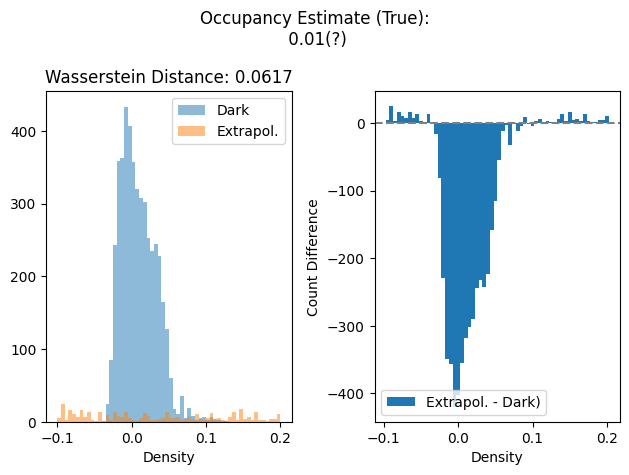

-0.12168033266478524
0.0050000000000000044
hist_dark max 433.0


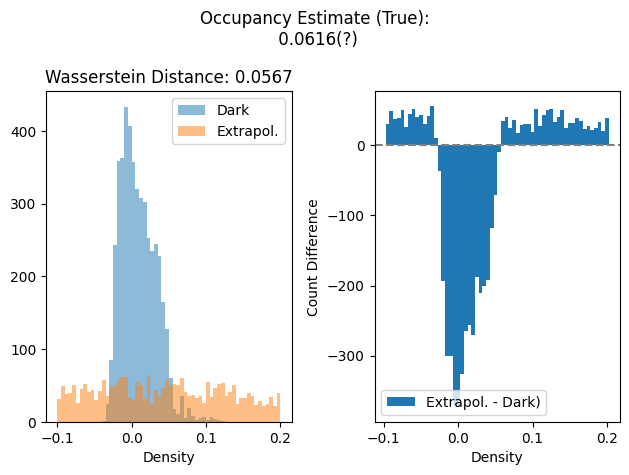

-0.749398331740002
0.0050000000000000044
hist_dark max 433.0


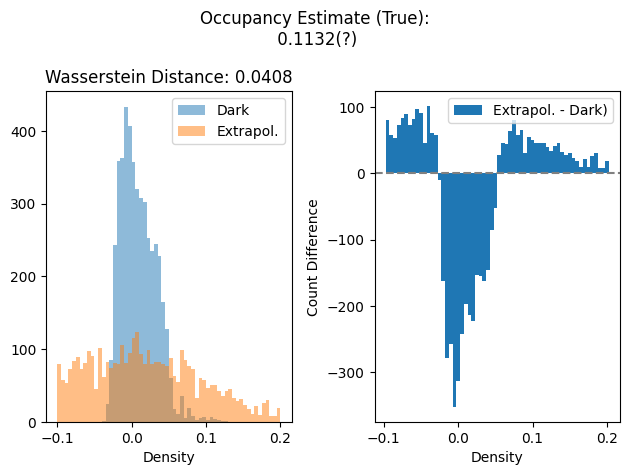

-1.14459540272157
0.0050000000000000044
hist_dark max 433.0


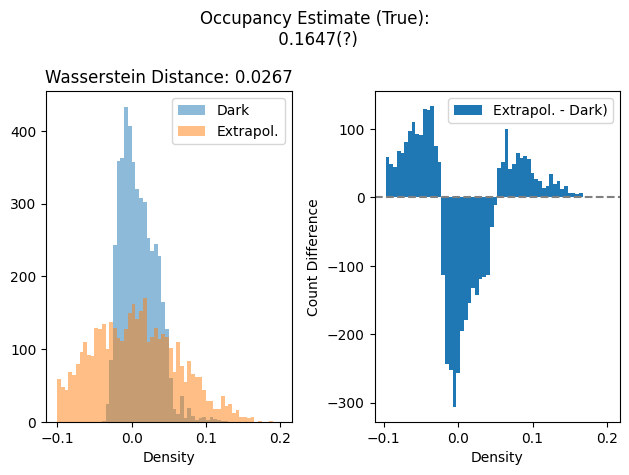

-1.4370104781048727
0.0050000000000000044
hist_dark max 433.0


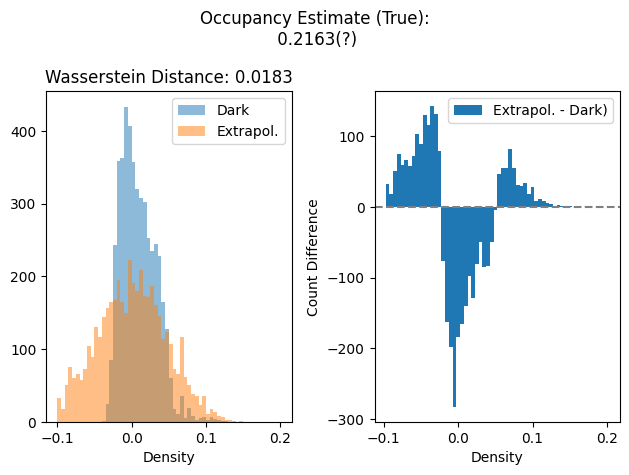

-1.6614757561279248
0.0050000000000000044
hist_dark max 433.0


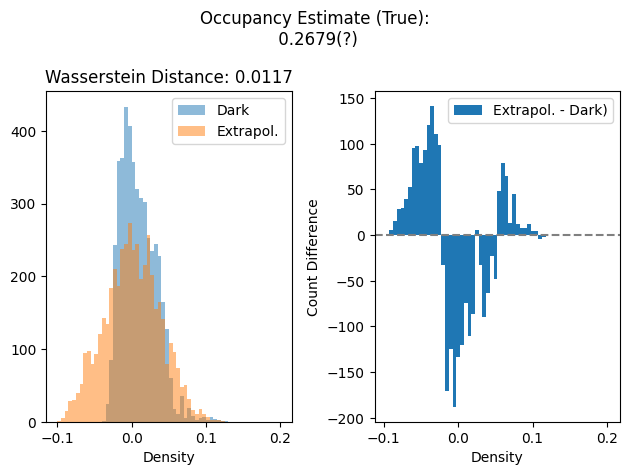

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


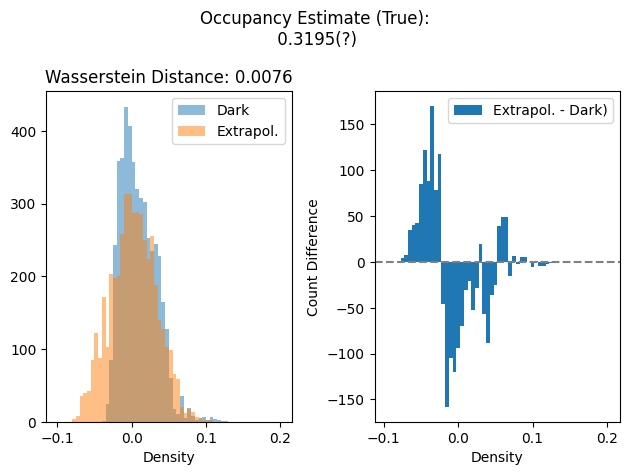

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


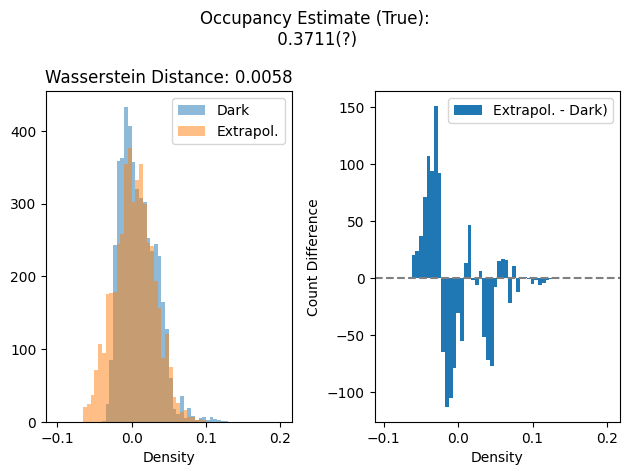

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


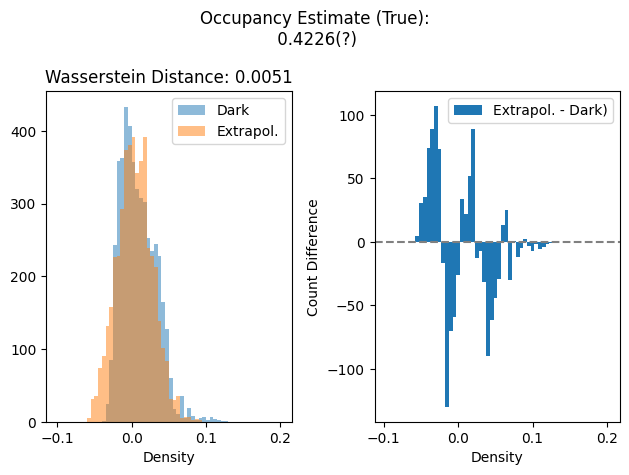

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


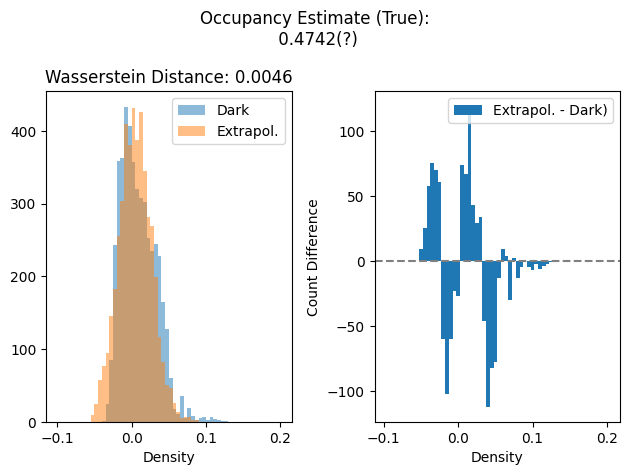

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


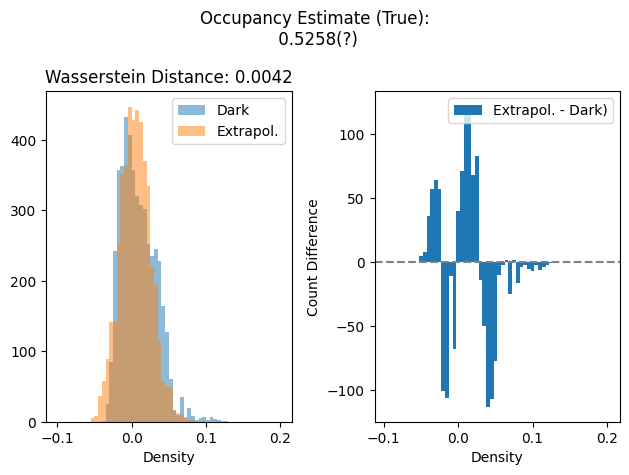

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


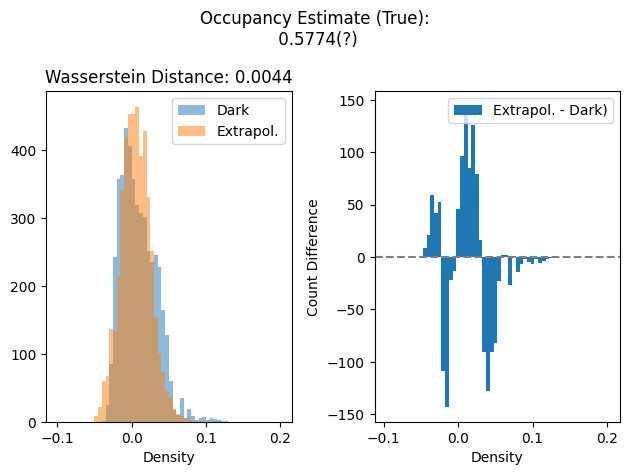

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


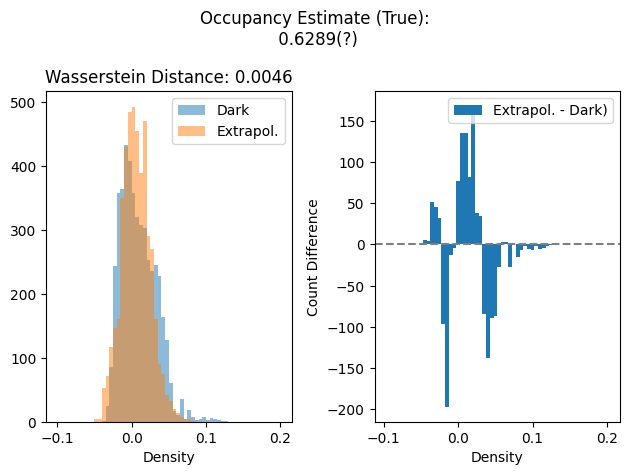

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


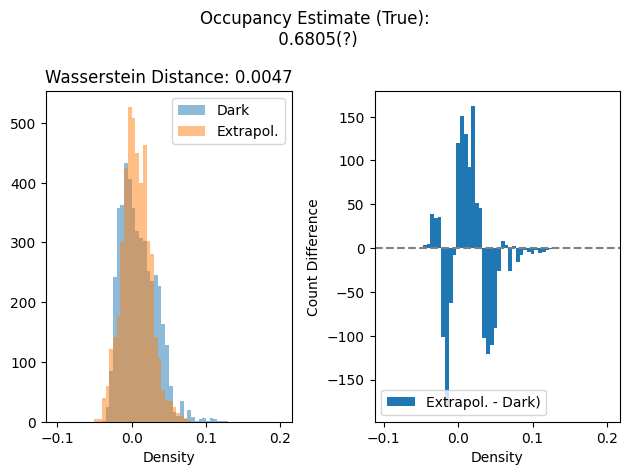

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


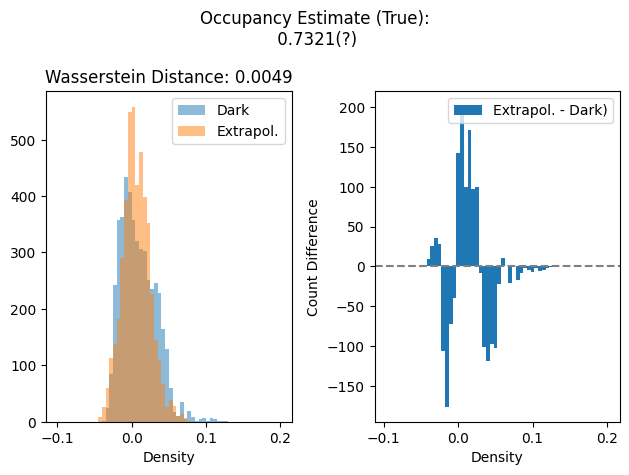

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


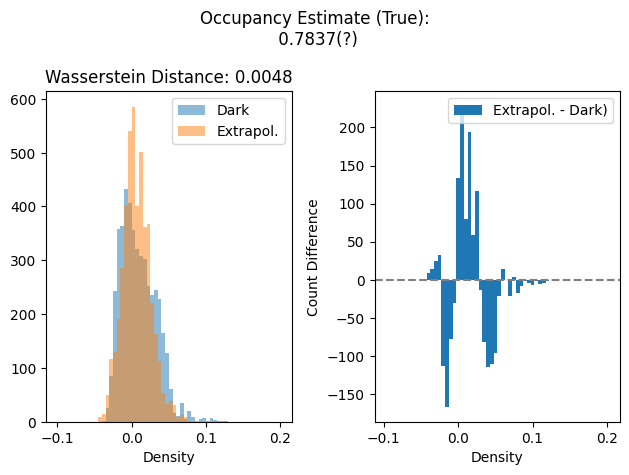

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


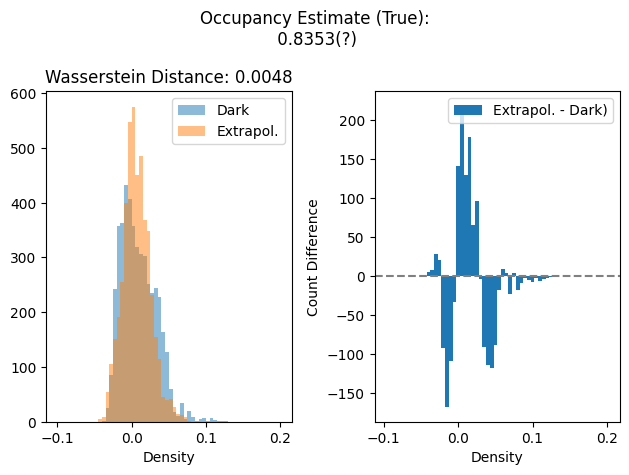

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


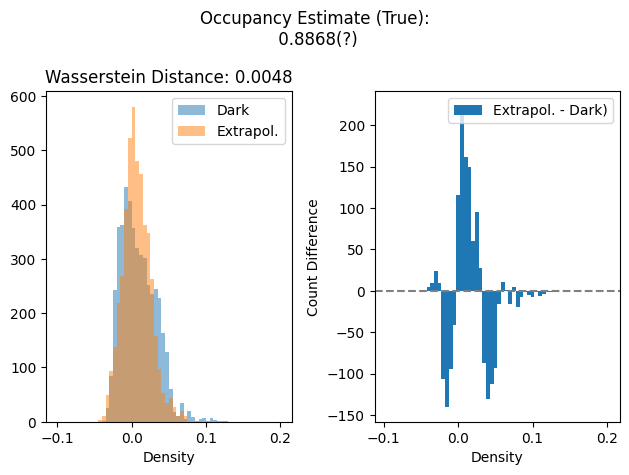

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


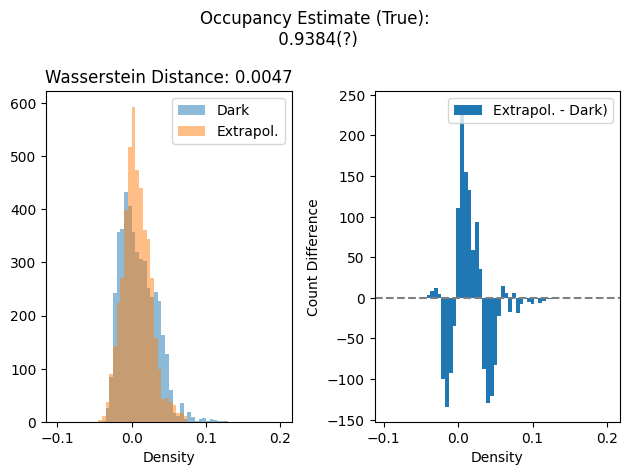

-1.7882172669876237
0.0050000000000000044
hist_dark max 433.0


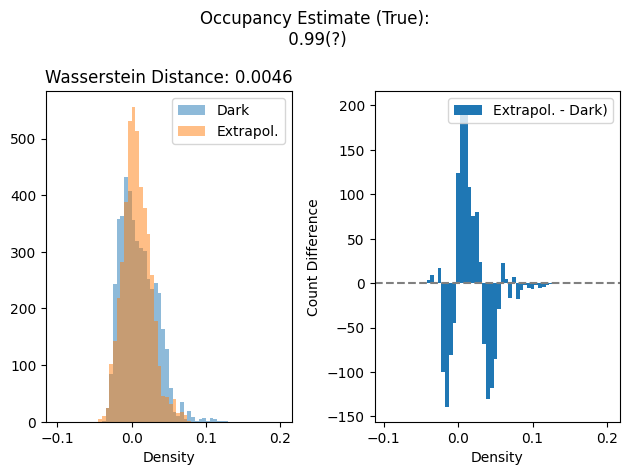

In [56]:
from plotting3d import val_distributions
config = {"alpha": "?", "zoom_in":False}
%matplotlib inline
plt.figure()
density_dark = rho_dark
dmin = np.min(density_dark)
dmax = np.max(density_dark)
bins = np.arange(-.5, .5, 0.005)
bins = np.arange(-.1, .2, 0.005)

wdists = []

for ii,(alpha_xtr, f_xtr) in enumerate(zip(alphas, f_xtrs)):
    config["alpha_xtr"] = np.round(alpha_xtr,4)
    dens_xtr = np.real(np.fft.ifftn(f_xtr))
    wasser_dist = val_distributions(
    density_dark,
        dens_xtr,
        mask_comb,
        # ~np.isnan(mask_truth),
        bins,
        config,
    )
    wdists.append(wasser_dist)
    plt.show()

In [57]:
len(alphas), len(f_xtrs)

(20, 20)

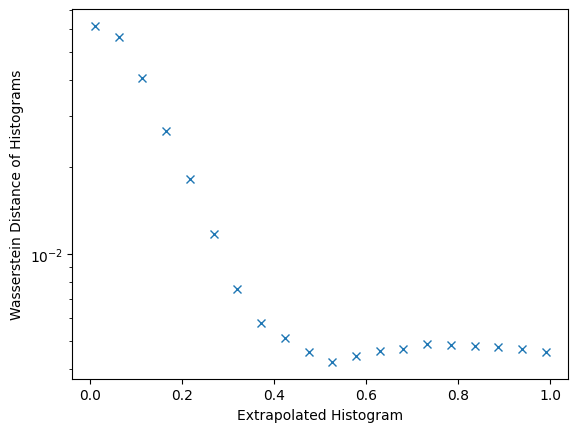

In [59]:
plt.figure()
plt.plot(alphas,wdists, "x")
plt.yscale("log")
plt.xlabel('Extrapolated Histogram')
plt.ylabel('Wasserstein Distance of Histograms')
plt.show()

In [93]:
f_delta = ds_comb.to_reciprocal_grid( "sf_delta")
f_light = ds_comb.to_reciprocal_grid( "sf_light")
f_dark[np.isnan(f_dark)]=0
f_light[np.isnan(f_light)]=0
print(f_dark[0,0,0])

from occupancy import make_f_xtr
f_angle = np.angle(f_dark)
# f_light[0,0,0] = -dmin*2


(10+0j)


In [149]:
f_light[np.isnan(f_light)]=0
f_dark[np.isnan(f_dark)]=0
print(f_dark[0,0,0])


0j


In [153]:
rho_dark =( np.fft.ifftn(f_dark))
dmin = np.min(rho_dark)
print("minimum")
print(dmin)
dmin = np.min(rho_dark-dmin)
dmin = np.min(rho_dark)
print(dmin)
f_dark_prime= np.fft.fftn(rho_dark-dmin)

# f_dark_prime-f_dark
print(np.sum((np.abs(f_dark_prime-f_dark))>1))
print(np.max(np.abs(f_dark_prime-f_dark)))
print(np.unravel_index(np.argmax(np.abs(f_dark_prime-f_dark)), f_dark.shape))
print(f_dark[0,0,0])
print(f_dark_prime[0,0,0])
# slice_3d()

# f_dark.size, 


minimum
(-0.04672461656292347-3.8333239438877315e-18j)
(-0.04672461656292347-3.8333239438877315e-18j)
1
1089991.8551798787
(0, 0, 0)
0j
(1089991.8551798787+8.9423780963013e-11j)


In [163]:
dmin = np.min(rho_dark)

f_dark_prime= f_dark.copy()
f_light_prime= f_light.copy()
f_dark_prime[0,0,0] =  -rho_dark.size*dmin
f_light_prime[0,0,0] =  -rho_dark.size*dmin

f_xtrs_prime =  make_f_xtr(alphas, f_dark_prime, f_light_prime, f_angle,version=1)
rho_dark_prime = np.fft.ifftn(f_dark_prime).real

1.7233188474574548
0.0050000000000000044
hist_dark max 419.0


<Figure size 640x480 with 0 Axes>

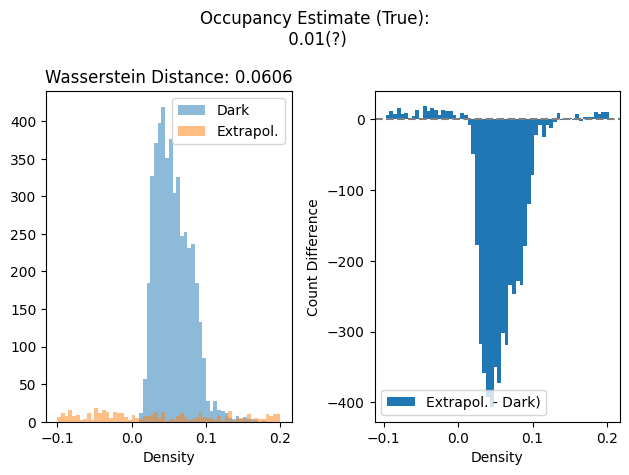

-0.07025511422736941
0.0050000000000000044
hist_dark max 419.0


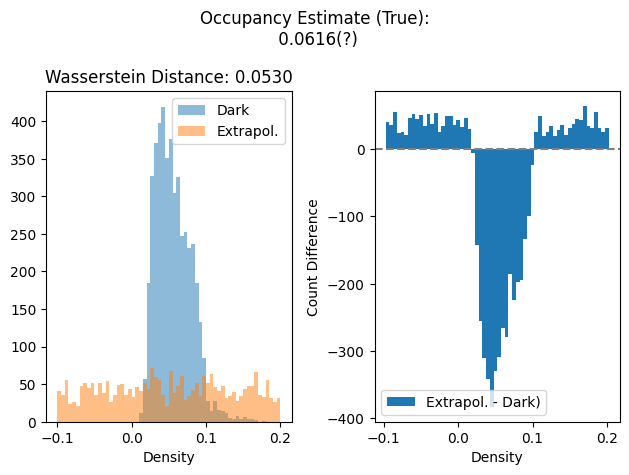

-0.655128222335686
0.0050000000000000044
hist_dark max 419.0


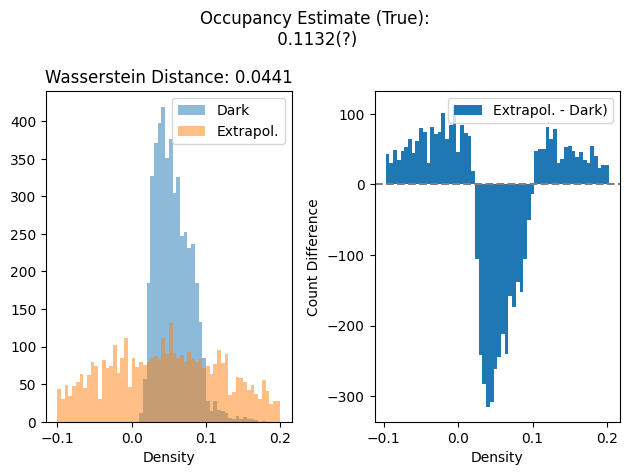

-1.0076461315709477
0.0050000000000000044
hist_dark max 419.0


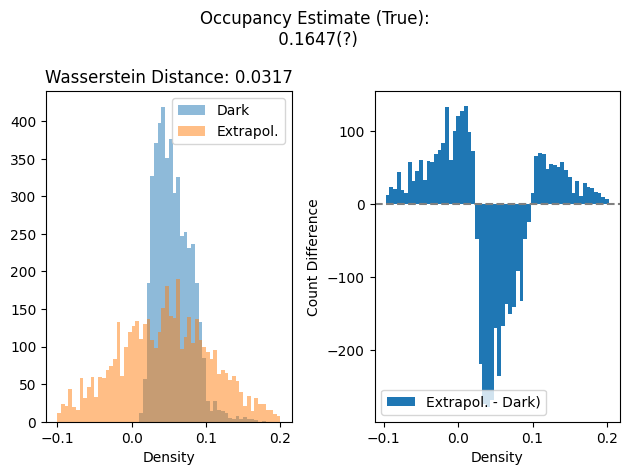

-1.2575081338345513
0.0050000000000000044
hist_dark max 419.0


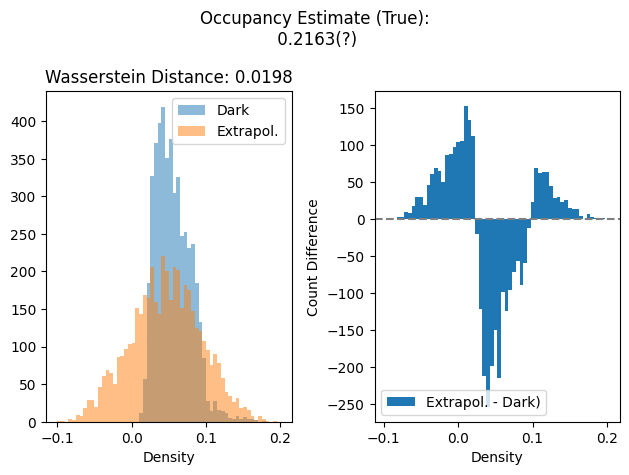

-1.441455315395888
0.0050000000000000044
hist_dark max 419.0


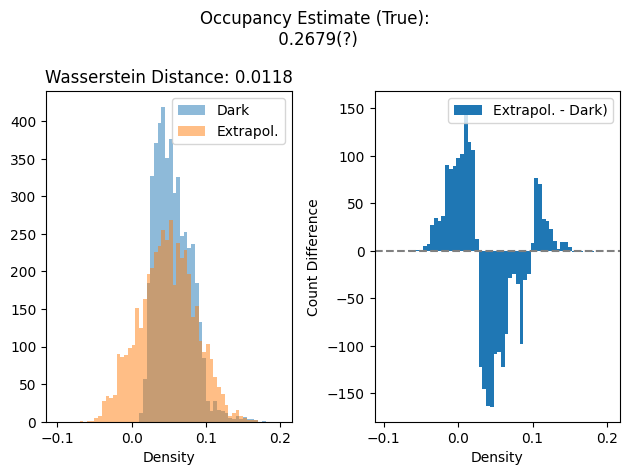

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


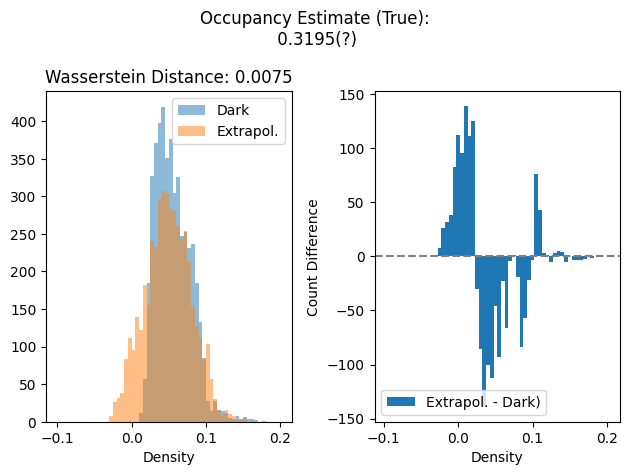

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


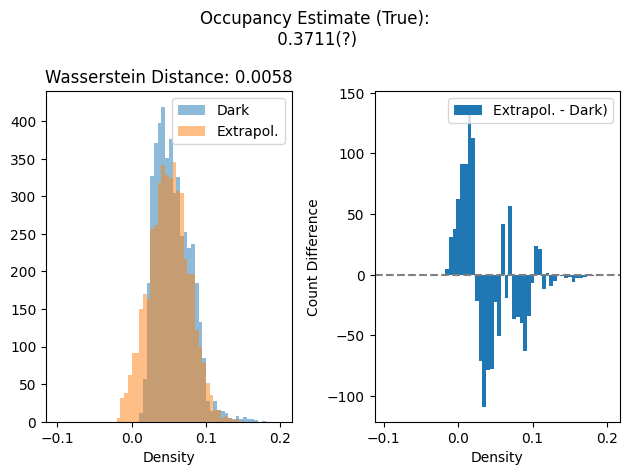

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


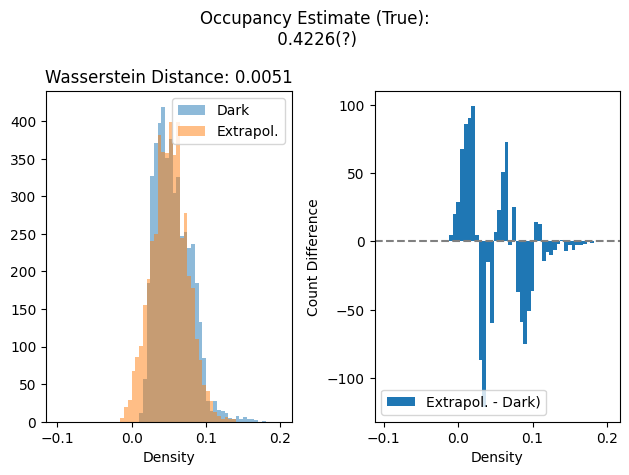

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


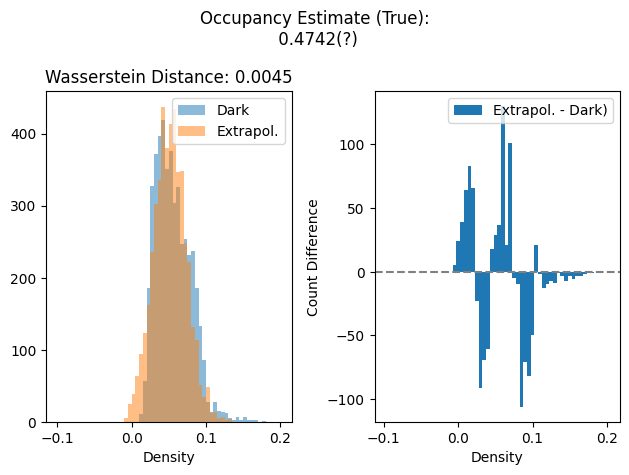

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


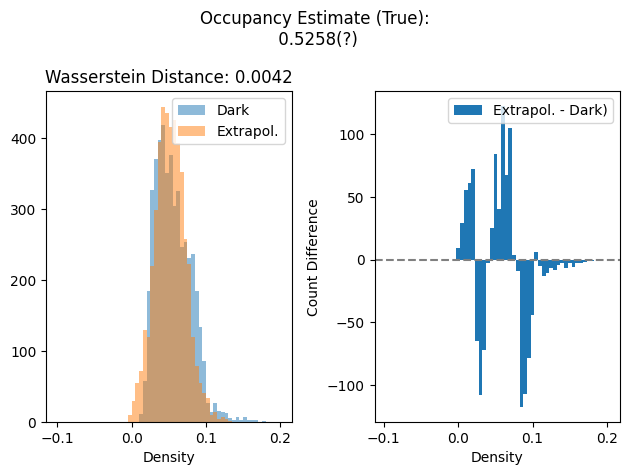

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


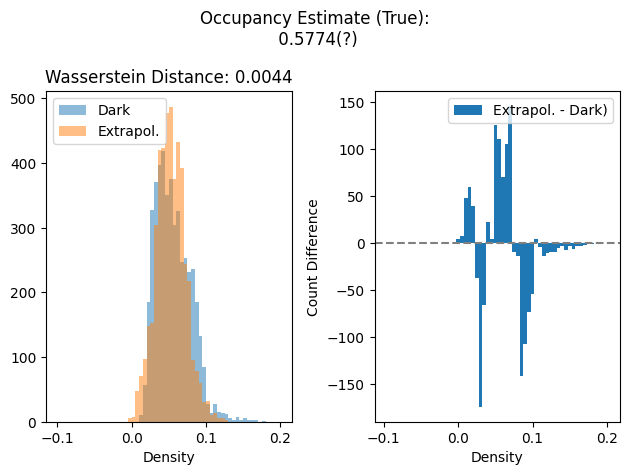

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


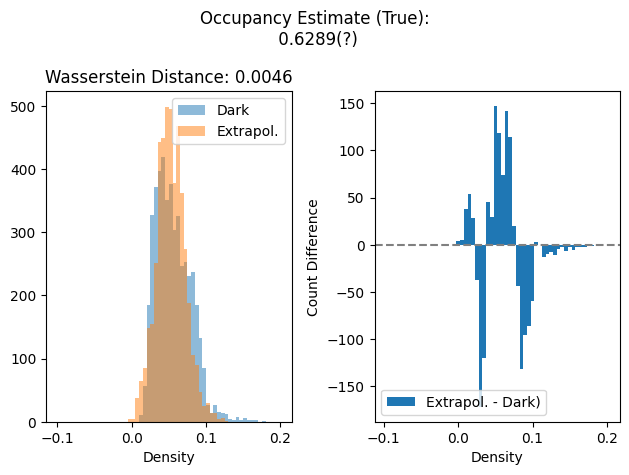

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


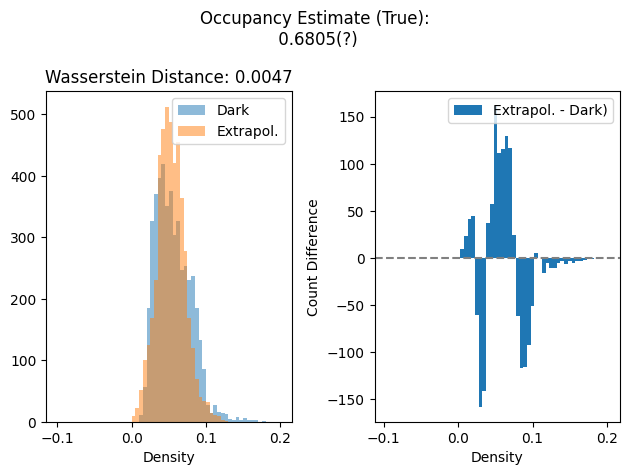

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


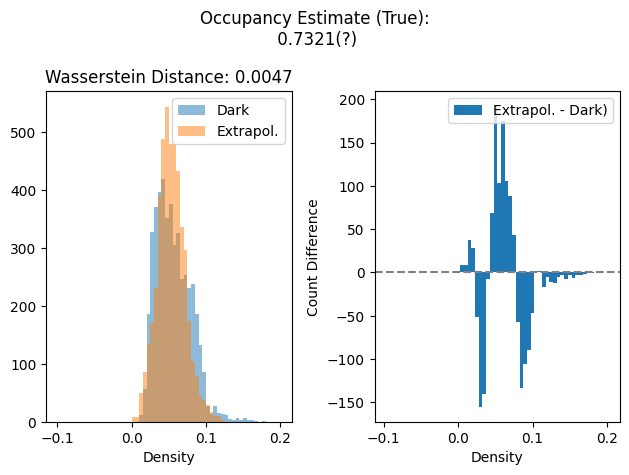

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


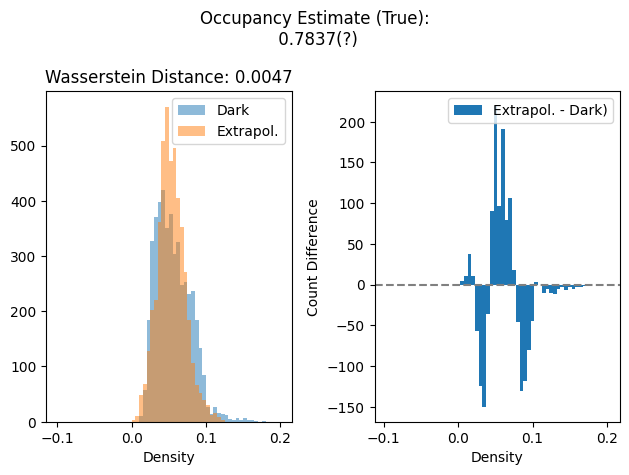

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


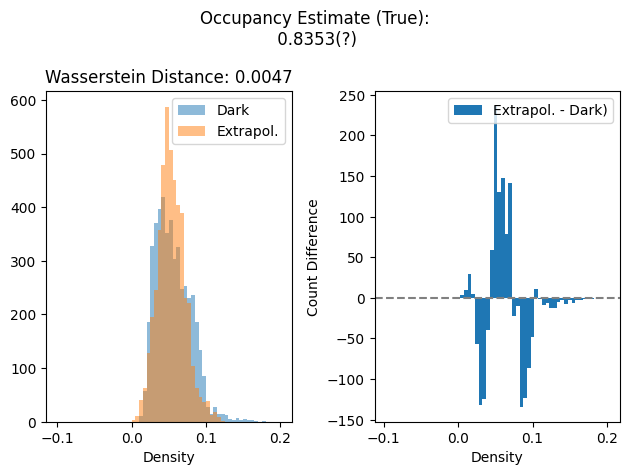

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


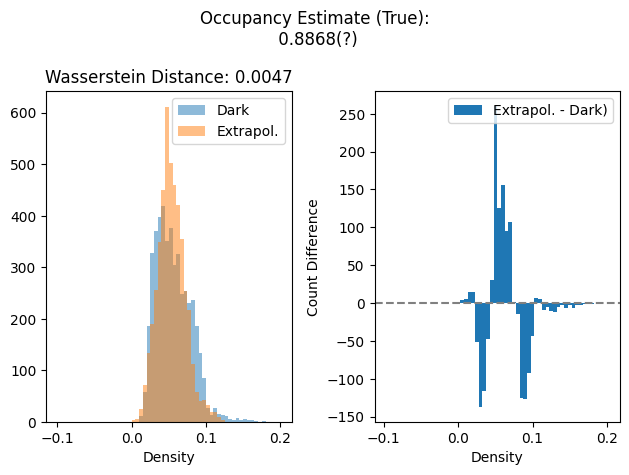

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


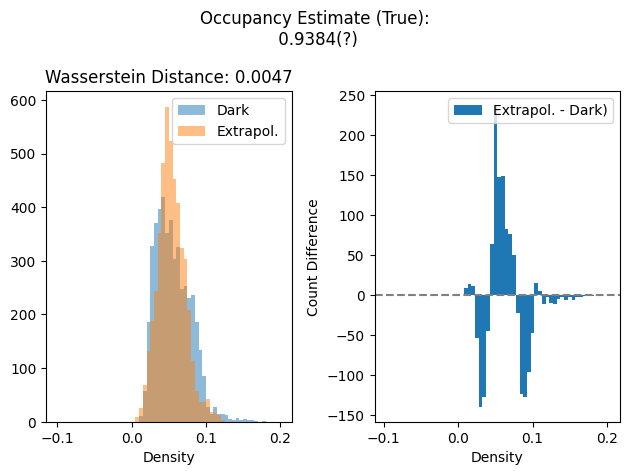

-1.541860121878464
0.0050000000000000044
hist_dark max 419.0


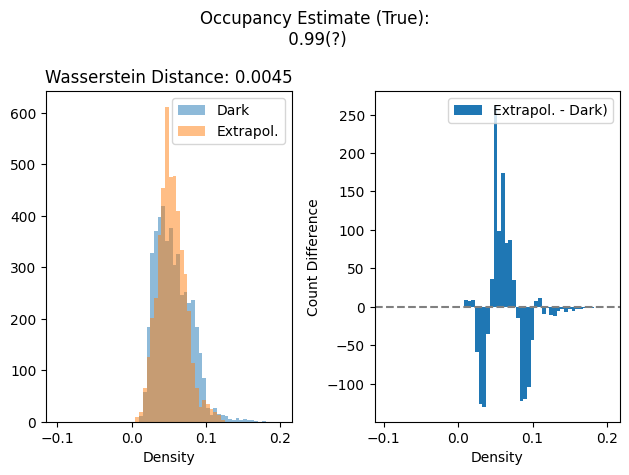

In [165]:
from plotting3d import val_distributions
config = {"alpha": "?", "zoom_in":False}
%matplotlib inline
plt.figure()
density_dark = rho_dark
# dmin = np.min(density_dark)
# dmax = np.max(density_dark)
bins = np.arange(-.5, .5, 0.005)
bins = np.arange(-.1, .2, 0.005)

wdists = []

for ii,(alpha_xtr, f_xtr) in enumerate(zip(alphas, f_xtrs_prime)):
    config["alpha_xtr"] = np.round(alpha_xtr,4)
    dens_xtr = np.real(np.fft.ifftn(f_xtr))
    wasser_dist = val_distributions(
    rho_dark_prime,
        dens_xtr,
        mask_comb,
        # ~np.isnan(mask_truth),
        bins,
        config,
    )
    wdists.append(wasser_dist)
    plt.show()

In [ ]:

arr = np.array(ds_dark.get_hkls())
np.max(arr, axis=0)

In [16]:
432/258, 180/108

(1.6744186046511629, 1.6666666666666667)